# How to use FENRIR data-driven kernels

written by Jean-Baptiste Delisle and Nathan Hara

This notebook gives an example of use of data-driven (dd) FENRIR kernels.

Suppose we have $q$ time series (or channels), not necessarily sampled at the same epochs.
The FENRIR dd kernels describing the covariance between channels $i$ and $j$ is 

$$
k_{i,j}(\tau; \boldsymbol{\eta}) = k^W(\tau; \boldsymbol{\eta}^W) \left( \sum\limits_{m=0}^{n_H} a_{i,j;m} \cos(m \omega \tau)  + b_{i,j;m} \sin(m \omega \tau) \right)
$$
where $\boldsymbol{\eta} =(\eta^W, a_{i,j;m}, b_{i,j;m}) $ is the vector of hyper parameters containing both the hyperparameters of the kernel $k^W$ and the coefficients of the periodic part of the kernel. 

$\mathbf{a}_m = (a_{i,j;m})_{i,j=1..q} $ and $\mathbf{b}_m = (b_{i,j;m})_{i,j=1..q} $ are symmetric $q\times q$ matrices, which in the FENRIR code are parametrized by the matrices $\boldsymbol{\alpha}_m$ and $\boldsymbol{\beta}_m$ (see Eq. 33 and 34 in Hara & Delisle 2025), such that 
$$
\mathbf{a}_m  = \boldsymbol{\alpha}_m \boldsymbol{\alpha}_m^T + \boldsymbol{\beta}_m \boldsymbol{\beta}_m^T 
$$
$$
\mathbf{b}_m  = \boldsymbol{\alpha}_m \boldsymbol{\beta}_m^T - \boldsymbol{\beta}_m \boldsymbol{\alpha}_m^T 
$$
and $ \boldsymbol{\beta}_0 = 0$.  $\boldsymbol{\alpha}_m$ is lower triangular, and  $\boldsymbol{\beta}_m$ is strictly lower triangular (diagonal is vanishing).

For instance, when choosing $n_H = 0$, the FENRIR data-driven kernel reduces to 
$$
k_{i,j}(\tau; \boldsymbol{\eta}) = a_{i,j;0}  k^W(\tau; \boldsymbol{\eta}^W)
$$
with $\mathbf{a}_0 =  \boldsymbol{\alpha}_0 \boldsymbol{\alpha}_0^T $. 

FENRIR allows to choose the number of ``modes'', which is the number of columns of $\alpha$. For instance, suppose you have $q=3$ channels. When we choose three modes, it means that 
$$ 
\boldsymbol{\alpha}_0 = 
\begin{pmatrix}
 \alpha_{11 }& 0  & 0 \\
 \alpha_{21 }& \alpha_{22 } & 0 \\
 \alpha_{31 }& \alpha_{32 } & \alpha_{33 }
\end{pmatrix}
$$
where all the $ \alpha_{ij }$  coefficients are free parameters. Choosing 1 mode means that we restrict the number of parameters to 
$$ 
\boldsymbol{\alpha}_0 = 
\begin{pmatrix}
 \alpha_{11 } \\
 \alpha_{21 } \\
 \alpha_{31 }
\end{pmatrix}
$$
The matrix  $\mathbf{a}_0 =\boldsymbol{\alpha}_0 \boldsymbol{\alpha}_0^T $ is still symmetric. Restricting the number of modes reduces the number of free parameters, but also reduces the expressivity of the model. 

The same simplifications can be applied to $\boldsymbol{\alpha}_m$ and $\boldsymbol{\beta}_m$ matrices describing higher order harmonics ($m=1,2...,n_H$).

If we choose $k^W$ as a semi-separable kernel (for instance Matérn-1/2 or 3/2), the cost of likelihood evaluation is proportional to the total number of data points (including all observation channels).

Below, we show an example of use of data driven kernels with different number of time-series. 


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fmin_l_bfgs_b
from spleaf import cov, term

## Generate time series 

The data used for the example is generated with a FENRIR kernel.

True alpha:
[[[ 0.09762701  0.          0.        ]
  [ 0.08976637 -0.1526904   0.        ]
  [-0.12482558  0.783546    0.92732552]
  [-0.23311696  0.58345008  0.05778984]
  [ 0.13608912  0.85119328 -0.85792788]]

 [[-0.8257414   0.          0.        ]
  [ 0.5563135   0.7400243   0.        ]
  [ 0.59831713 -0.07704128  0.56105835]
  [-0.76345115  0.27984204 -0.71329343]
  [ 0.88933783  0.04369664 -0.17067612]]

 [[-0.47088878  0.          0.        ]
  [ 0.1368679  -0.9624204   0.        ]
  [ 0.22419145  0.23386799  0.88749616]
  [ 0.3636406  -0.2809842  -0.12593609]
  [ 0.39526239 -0.87954906  0.33353343]]]
True beta:
[[[ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]]

 [[ 0.          0.          0.        ]
  [-0.7236341   0.          0.        ]
  [ 0.64198646 -0.80579745  0.        ]
  [-0.80780318  0.95291893 -0.0626976 ]
  [ 0.953

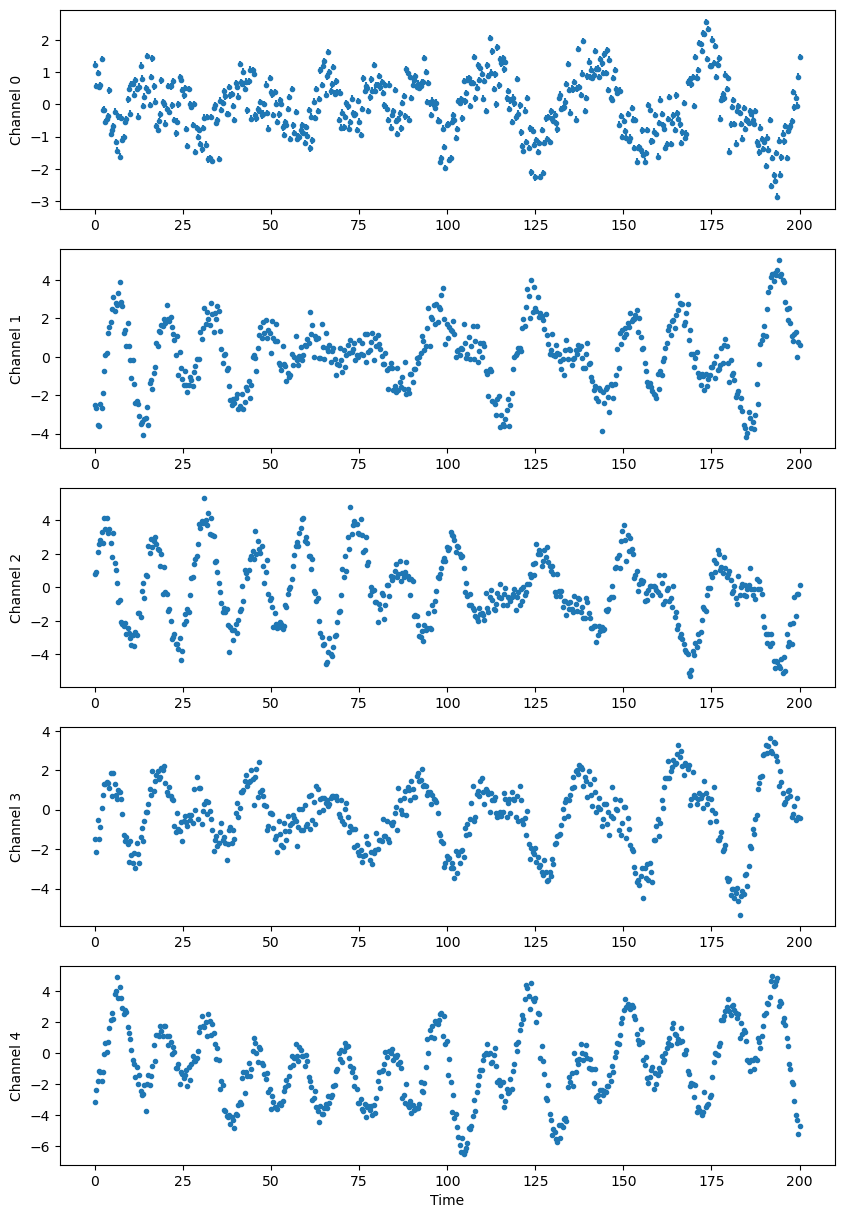

In [2]:
nseries = 5  # Number of different time-series, q in the equations above
nharm = 2  # Number of harmonics in the model, n_H in the equations above
nmode = 3  # Number of modes (same for each frequency) Between 1 and nseries

np.random.seed(0)
true_alpha = np.random.uniform(-1, 1, (nharm + 1, nseries, nmode))
true_beta = np.random.uniform(-1, 1, (nharm + 1, nseries, nmode))
for k in range(nmode):
  true_alpha[:, :k, k] = 0
  true_beta[:, : k + 1, k] = 0
true_beta[0] = 0
print('True alpha:')
print(true_alpha)
print('True beta:')
print(true_beta)

P = 27.3
rho = 2 * P

sig_jit = 0.5

Tspan = 200
nt = 542
t = np.linspace(0, Tspan, nt)
ts = [t for _ in range(nseries)]
sigs = np.full((nseries, t.size), 0.1)

full_t, full_sig, series_index = cov.merge_series(ts, sigs)

Cgen = cov.Cov(
  full_t,
  err=term.Error(full_sig),
  jit=term.Jitter(sig_jit),
  gp=term.SimpleProductKernel(
    decay=term.Matern32Kernel(1, rho),
    fourier=term.MultiFourierKernel(P, true_alpha, true_beta, series_index),
  ),
)

full_y = Cgen.sample()
ys = [full_y[inds] for inds in series_index]

_, axs = plt.subplots(nseries, 1, figsize=(10, 3 * nseries))
for k in range(nseries):
  axs[k].errorbar(t, ys[k], sigs[k], fmt='.', rasterized=True)
  axs[k].set_ylabel(f'Channel {k}')

plt.xlabel('Time')
plt.show()

## Fitting the Fenrir dd model

In [3]:
alpha = true_alpha.copy()
beta = true_beta.copy()

Cfit = cov.Cov(
  full_t,
  err=term.Error(full_sig),
  jit=term.Jitter(sig_jit),
  gp=term.SimpleProductKernel(
    decay=term.Matern32Kernel(1, rho),
    fourier=term.MultiFourierKernel(P, alpha, beta, series_index),
  ),
)

if nharm > 0:
  cov_param = ['gp.decay_rho', 'gp.fourier_P']
else:
  cov_param = ['gp.decay_rho']
for h in range(nharm + 1):
  cov_param += [
    f'gp.fourier_{ab}_{h}_{k}_{s}'
    for k in range(nseries)
    for s in range(min(1 + k, nmode))
    for ab in ['alpha', 'beta'][: ((min(k - s, h) > 0) + 1)]
  ]


def negloglike(x, with_grad=True):
  # Split offsets and covariance parameters
  xoff, xcov = x[:nseries], x[nseries:]

  # Substract offsets from time series
  res = full_y.copy()
  for k in range(nseries):
    res[series_index[k]] -= xoff[k]

  # Set covariance parameters
  Cfit.set_param(xcov, cov_param)
  nll = -Cfit.loglike(res)
  if with_grad:
    gy, gcov = Cfit.loglike_grad()
    ngrad = np.array(
      [np.sum(gy[series_index[k]]) for k in range(nseries)]
      + [-g for par, g in zip(Cfit.param, gcov) if par in cov_param]
    )
    return (nll, ngrad)
  return nll


x0 = np.concatenate((np.zeros(nseries), Cfit.get_param(cov_param)))
x, _, _ = fmin_l_bfgs_b(negloglike, x0)

xoff, xcov = x[:nseries], x[nseries:]
Cfit.set_param(xcov, cov_param)
res = full_y.copy()
for k in range(nseries):
  res[series_index[k]] -= xoff[k]

## Value of the fitted parameters

In [4]:
print('--- Offsets (intercepts) ---')
for i in range(nseries):
  print(f'Offset channel {i} = {xoff[i]}')
print('\n--- Covariance parameters ---')
for key, val in zip(cov_param, xcov):
  if 'alpha' not in key and 'beta' not in key:
    print(f'{key} = {val}')
print('alpha =')
print(alpha)
print('beta =')
print(beta)

--- Offsets (intercepts) ---
Offset channel 0 = -0.0035341542762968798
Offset channel 1 = -0.007033408789626501
Offset channel 2 = 0.0006325328800607173
Offset channel 3 = -0.00426944081277358
Offset channel 4 = 0.00043893550467862555

--- Covariance parameters ---
gp.decay_rho = 54.60020470611014
gp.fourier_P = 27.29877823445218
alpha =
[[[ 0.10174108  0.          0.        ]
  [ 0.09318836 -0.15065085  0.        ]
  [-0.12554609  0.7824079   0.92356375]
  [-0.22937721  0.58099932  0.06295525]
  [ 0.13576373  0.85099004 -0.85916783]]

 [[-0.8266191   0.          0.        ]
  [ 0.55498183  0.73752969  0.        ]
  [ 0.60042474 -0.07181987  0.55495211]
  [-0.76317123  0.27772392 -0.72027535]
  [ 0.88942372  0.04415967 -0.18309692]]

 [[-0.46647609  0.          0.        ]
  [ 0.13708971 -0.9564535   0.        ]
  [ 0.23208398  0.24011259  0.89145366]
  [ 0.37286406 -0.28475249 -0.12116637]
  [ 0.39116502 -0.88253968  0.34090819]]]
beta =
[[[ 0.          0.          0.        ]
  [ 0. 

## Plot the conditional distribution

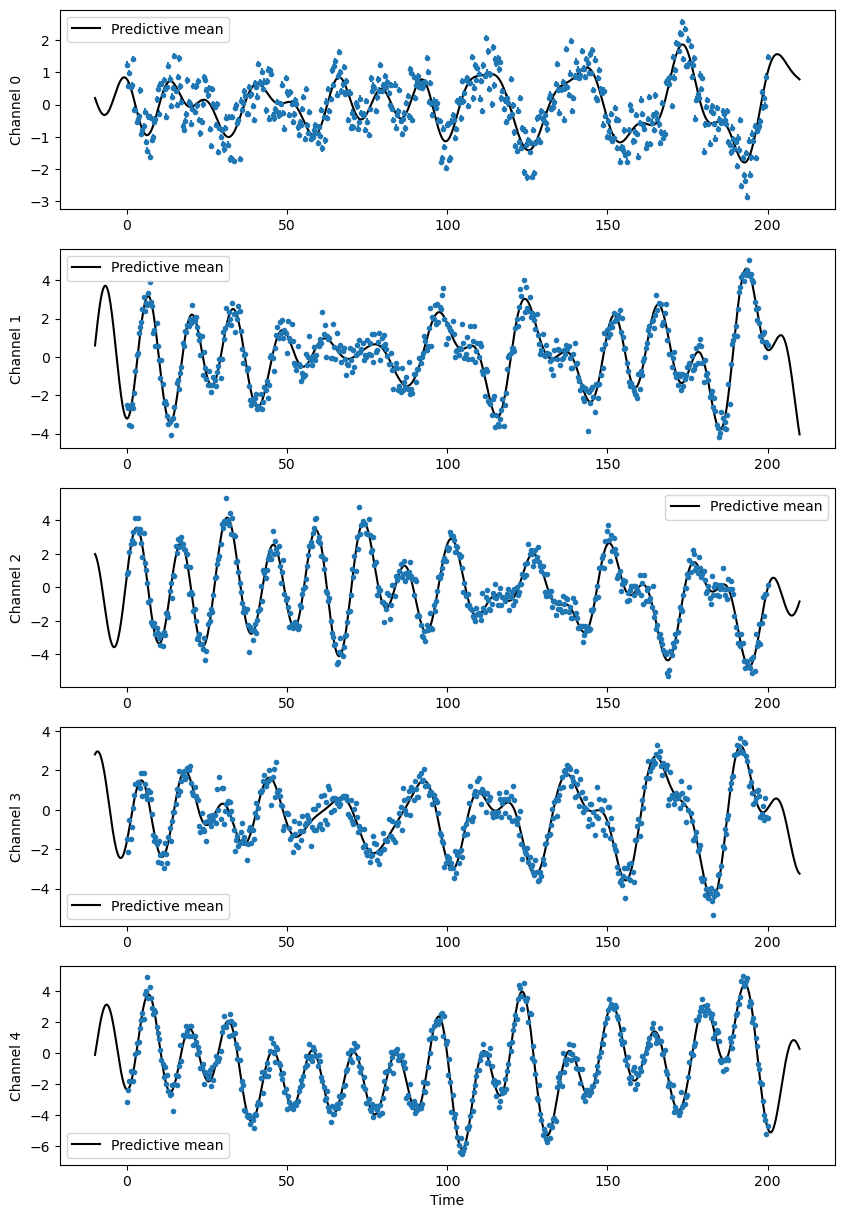

In [5]:
tpred = np.linspace(-Tspan / 20, Tspan + Tspan / 20, 2000)

_, axs = plt.subplots(nseries, 1, figsize=(10, 3 * nseries))
for k in range(nseries):
  Cfit.kernel['gp'].set_conditional_coef(series_id=k)
  mu = Cfit.conditional(res, tpred)
  axs[k].errorbar(t, res[series_index[k]], sigs[k], fmt='.', rasterized=True)
  axs[k].plot(tpred, mu, 'k-', rasterized=True, label='Predictive mean')
  axs[k].set_ylabel(f'Channel {k}')
  axs[k].legend()

plt.xlabel('Time')
plt.show()